# Modelling
## Setup

In [1]:
%pip install seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score, classification_report, confusion_matrix

df = pd.read_csv('features.csv')
drop_cols = ['speaker_id', 'class', 'gender', 'location', 'notes', 'file_path', 'file_path_processed']
bias_cols = [c for c in df.columns if (c.startswith('mfcc') and c.endswith('_mean')) or c in ['f0_mean', 'f1_mean', 'f2_mean', 'f1f2_ratio']]
feature_cols = [c for c in df.columns if c not in drop_cols and c not in bias_cols]
X = df[feature_cols].values
y = df['class'].values
groups = df['speaker_id'].values
print(f"Menggunakan {len(feature_cols)} fitur dinamis dari total {df.shape[1]} kolom.")
logo = LeaveOneGroupOut()

models = {
    'Logistic Regression': lambda: LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    'SVM (Linear)': lambda: SVC(kernel='linear', class_weight='balanced', probability=True, random_state=42),
    'Gradient Boosting': lambda: GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': lambda: SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    'Random Forest': lambda: RandomForestClassifier(n_estimators=300, max_depth=5, class_weight='balanced', random_state=42)
}


[notice] A new release of pip is available: 23.3.2 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Menggunakan 73 fitur dinamis dari total 92 kolom.


## Loop LOSO per classifier

In [2]:
def run_loso(make_model, name):
    y_true, y_pred, y_prob = [], [], []
    for train_idx, test_idx in logo.split(X, y, groups):
        Xtr, Xte = X[train_idx], X[test_idx]
        ytr = y[train_idx]
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('selector', SelectKBest(score_func=f_classif, k=min(15, Xtr.shape[1]))),
            ('classifier', make_model())
        ])
        pipeline.fit(Xtr, ytr)
        # Label asli (diambil satu karena kelimanya pasti sama untuk 1 speaker)
        y_true.append(y[test_idx[0]])

        # Dapatkan array berisi 5 prediksi dan 5 probabilitas untuk ke-5 file
        preds = pipeline.predict(Xte)
        probas = pipeline.predict_proba(Xte)
            
        native_idx = list(pipeline.classes_).index('native')
            
        # --- AGREGASI LEVEL SPEAKER ---
        # 1. Rata-rata Nativeness Score dari 5 file
        mean_proba = np.mean(probas[:, native_idx])
        y_prob.append(mean_proba)
            
        # 2. Majority Voting (Prediksi Akhir)
         # Jika probabilitas rata-rata > 0.5, anggap native, jika tidak learner
        final_pred = 'native' if mean_proba > 0.5 else 'learner'
        y_pred.append(final_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"=== {name} ===")
    print(f"Balanced Acc : {bal_acc:.2%}")
    print(f"Macro F1     : {macro_f1:.2%}")
    print(classification_report(y_true, y_pred, labels=['native', 'learner']))
    return np.array(y_true), np.array(y_pred), np.array(y_prob)

## Jalankan semua model

In [3]:
results = {}
for name, make_model in models.items():
    results[name] = run_loso(make_model, name)

metrics_df = pd.DataFrame([
    {
        'model': name,
        'balanced_accuracy': balanced_accuracy_score(values[0], values[1]),
        'macro_f1': f1_score(values[0], values[1], average='macro')
    }
    for name, values in results.items()
])
print('Ringkasan semua model:')
display(metrics_df.sort_values('balanced_accuracy', ascending=False))

=== Logistic Regression ===
Balanced Acc : 91.67%
Macro F1     : 91.61%
              precision    recall  f1-score   support

      native       1.00      0.83      0.91         6
     learner       0.86      1.00      0.92         6

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12

=== SVM (Linear) ===
Balanced Acc : 83.33%
Macro F1     : 82.86%
              precision    recall  f1-score   support

      native       1.00      0.67      0.80         6
     learner       0.75      1.00      0.86         6

    accuracy                           0.83        12
   macro avg       0.88      0.83      0.83        12
weighted avg       0.88      0.83      0.83        12



/home/kopiadem/Documents/MASTER/1. SEM-1/pengenalan-pola/assignment1/jp-native-vs-learner/.venv/lib64/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/kopiadem/Documents/MASTER/1. SEM-1/pengenalan-pola/assignment1/jp-native-vs-learner/.venv/lib64/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/kopiadem/Documents/MASTER/1. SEM-1/pengenalan-pola/assignment1/jp-native-vs-learner/.venv/lib64/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV

=== Gradient Boosting ===
Balanced Acc : 100.00%
Macro F1     : 100.00%
              precision    recall  f1-score   support

      native       1.00      1.00      1.00         6
     learner       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12

=== SVM (RBF) ===
Balanced Acc : 91.67%
Macro F1     : 91.61%
              precision    recall  f1-score   support

      native       1.00      0.83      0.91         6
     learner       0.86      1.00      0.92         6

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12



/home/kopiadem/Documents/MASTER/1. SEM-1/pengenalan-pola/assignment1/jp-native-vs-learner/.venv/lib64/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/kopiadem/Documents/MASTER/1. SEM-1/pengenalan-pola/assignment1/jp-native-vs-learner/.venv/lib64/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/kopiadem/Documents/MASTER/1. SEM-1/pengenalan-pola/assignment1/jp-native-vs-learner/.venv/lib64/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV

=== Random Forest ===
Balanced Acc : 91.67%
Macro F1     : 91.61%
              precision    recall  f1-score   support

      native       1.00      0.83      0.91         6
     learner       0.86      1.00      0.92         6

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12

Ringkasan semua model:


,model,balanced_accuracy,macro_f1
2,Gradient Boosting,1.000000,1.000000
0,Logistic Regression,0.916667,0.916084
3,SVM (RBF),0.916667,0.916084
4,Random Forest,0.916667,0.916084
1,SVM (Linear),0.833333,0.828571


## Visualisasi hasil semua model

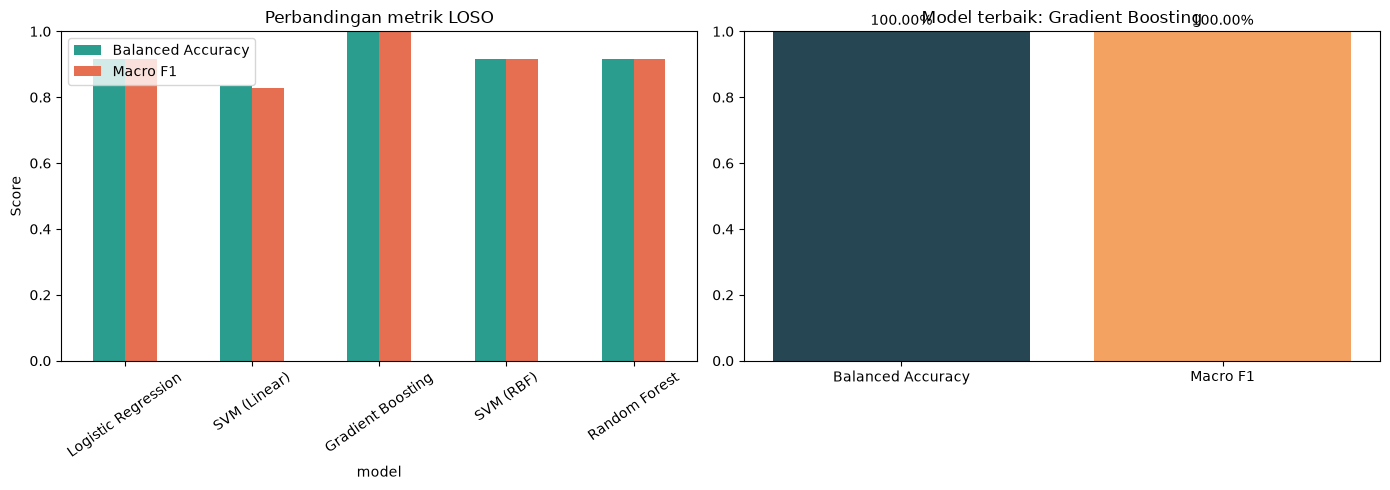

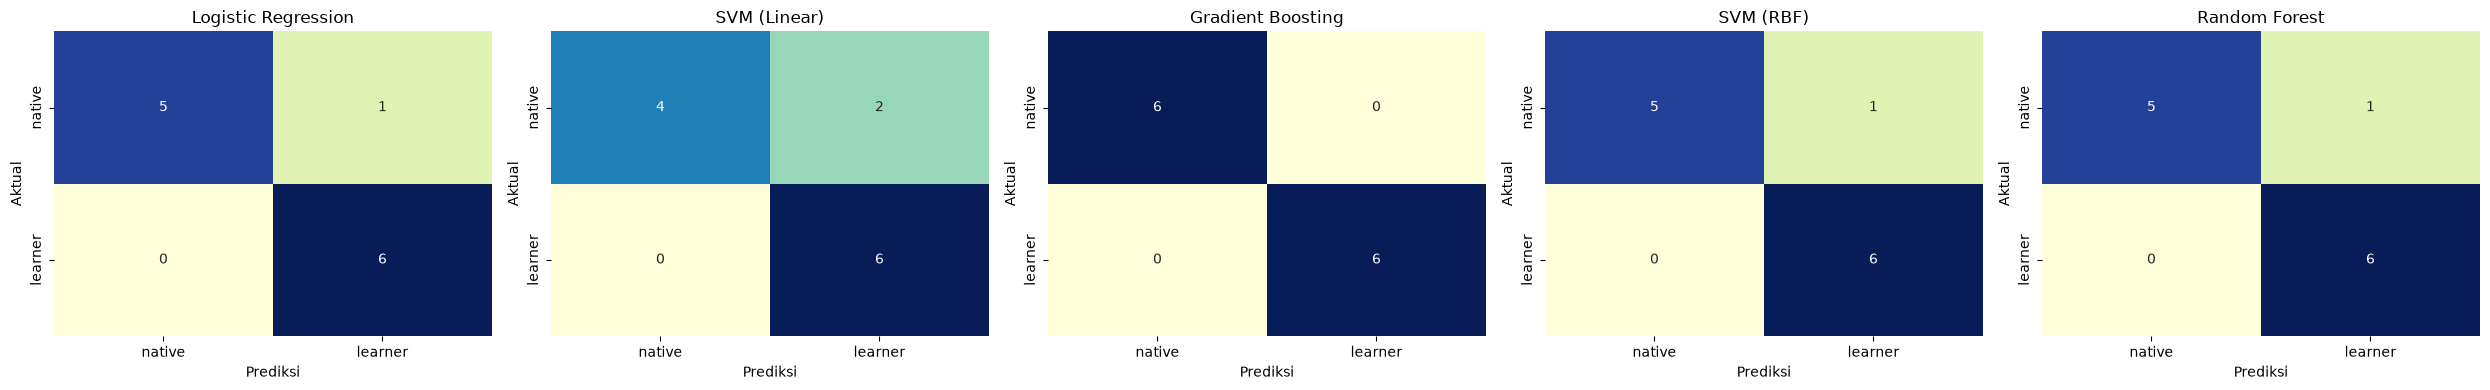

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = metrics_df.set_index('model')
plot_df[['balanced_accuracy', 'macro_f1']].plot(kind='bar', ax=axes[0], color=['#2a9d8f', '#e76f51'])
axes[0].set_title('Perbandingan metrik LOSO')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(['Balanced Accuracy', 'Macro F1'])
for model_name, values in plot_df[['balanced_accuracy', 'macro_f1']].iterrows():
    pass
best_name = plot_df['balanced_accuracy'].idxmax()
axes[1].bar(['Balanced Accuracy', 'Macro F1'], plot_df.loc[best_name, ['balanced_accuracy', 'macro_f1']], color=['#264653', '#f4a261'])
axes[1].set_title(f'Model terbaik: {best_name}')
axes[1].set_ylim(0, 1)
for index, value in enumerate(plot_df.loc[best_name, ['balanced_accuracy', 'macro_f1']]):
    axes[1].text(index, value + 0.02, f'{value:.2%}', ha='center')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
axes = np.atleast_1d(axes)
for axis, (name, (y_true, y_pred, _)) in zip(axes, results.items()):
    cm = confusion_matrix(y_true, y_pred, labels=['native', 'learner'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False, ax=axis,
                xticklabels=['native', 'learner'], yticklabels=['native', 'learner'])
    axis.set_title(name)
    axis.set_xlabel('Prediksi')
    axis.set_ylabel('Aktual')
plt.tight_layout()
plt.show()

## Native Score per speaker

In [5]:
for name, (y_true, y_pred, y_prob) in results.items():
    score_df = pd.DataFrame({
        'speaker_id': np.unique(groups),
        'true': y_true,
        'pred': y_pred,
        'nativeness_score': y_prob,
    })
    score_df = score_df.merge(pd.read_csv('metadata_utterance.csv')[['speaker_id', 'gender', 'location']].drop_duplicates('speaker_id'), on='speaker_id')
    score_df.to_csv(f"nativeness_{name.split()[0].lower()}.csv", index=False)
    print(f"\n--- {name}: nativeness score per speaker ---")
    display(score_df.sort_values('nativeness_score'))


--- Logistic Regression: nativeness score per speaker ---


,speaker_id,true,pred,nativeness_score,gender,location
5,learner06,learner,learner,0.039847,M,indoor
3,learner04,learner,learner,0.050315,M,indoor
2,learner03,learner,learner,0.051543,M,indoor
1,learner02,learner,learner,0.165877,M,indoor
0,learner01,learner,learner,0.252177,M,indoor
6,native01,native,learner,0.401697,M,cafe
4,learner05,learner,learner,0.464477,F,indoor
11,native06,native,native,0.516665,M,indoor
7,native02,native,native,0.775601,M,cafe
9,native04,native,native,0.871120,F,cafe



--- SVM (Linear): nativeness score per speaker ---


,speaker_id,true,pred,nativeness_score,gender,location
5,learner06,learner,learner,0.057646,M,indoor
2,learner03,learner,learner,0.113872,M,indoor
3,learner04,learner,learner,0.176391,M,indoor
0,learner01,learner,learner,0.250032,M,indoor
6,native01,native,learner,0.306812,M,cafe
1,learner02,learner,learner,0.326727,M,indoor
11,native06,native,learner,0.364669,M,indoor
4,learner05,learner,learner,0.382113,F,indoor
7,native02,native,native,0.693958,M,cafe
10,native05,native,native,0.788053,F,cafe



--- Gradient Boosting: nativeness score per speaker ---


,speaker_id,true,pred,nativeness_score,gender,location
1,learner02,learner,learner,0.000024,M,indoor
2,learner03,learner,learner,0.000024,M,indoor
3,learner04,learner,learner,0.012588,M,indoor
0,learner01,learner,learner,0.200015,M,indoor
4,learner05,learner,learner,0.200015,F,indoor
5,learner06,learner,learner,0.200015,M,indoor
6,native01,native,native,0.599994,M,cafe
11,native06,native,native,0.902615,M,indoor
10,native05,native,native,0.935925,F,cafe
7,native02,native,native,0.999976,M,cafe



--- SVM (RBF): nativeness score per speaker ---


,speaker_id,true,pred,nativeness_score,gender,location
5,learner06,learner,learner,0.028926,M,indoor
2,learner03,learner,learner,0.140071,M,indoor
1,learner02,learner,learner,0.190408,M,indoor
3,learner04,learner,learner,0.195944,M,indoor
0,learner01,learner,learner,0.339722,M,indoor
6,native01,native,learner,0.413462,M,cafe
4,learner05,learner,learner,0.424505,F,indoor
11,native06,native,native,0.501753,M,indoor
10,native05,native,native,0.818912,F,cafe
7,native02,native,native,0.843995,M,cafe



--- Random Forest: nativeness score per speaker ---


,speaker_id,true,pred,nativeness_score,gender,location
5,learner06,learner,learner,0.167556,M,indoor
2,learner03,learner,learner,0.212484,M,indoor
3,learner04,learner,learner,0.219935,M,indoor
1,learner02,learner,learner,0.285402,M,indoor
4,learner05,learner,learner,0.374133,F,indoor
0,learner01,learner,learner,0.425500,M,indoor
6,native01,native,learner,0.449778,M,cafe
11,native06,native,native,0.616250,M,indoor
9,native04,native,native,0.772450,F,cafe
7,native02,native,native,0.794660,M,cafe


## Gender Stratified

In [9]:
best_name = metrics_df.loc[metrics_df['balanced_accuracy'].idxmax(), 'model']
y_true, y_pred, y_prob = results[best_name]
chk = pd.DataFrame({'speaker_id': np.unique(groups), 'true': y_true, 'pred': y_pred, 'score': y_prob}).merge(
    pd.read_csv('metadata_utterance.csv')[['speaker_id', 'gender']].drop_duplicates('speaker_id'), on='speaker_id')
male = chk[chk['gender'] == 'M']
print(f"Male speakers  : {male['pred'].eq(male['true']).mean():.2%} benar ({male['pred'].eq(male['true']).sum()}/{len(male)})")

Male speakers  : 100.00% benar (8/8)


In [10]:
best_name = metrics_df.loc[metrics_df['balanced_accuracy'].idxmax(), 'model']
y_true, y_pred, y_prob = results[best_name]
chk = pd.DataFrame({'speaker_id': np.unique(groups), 'true': y_true, 'pred': y_pred, 'score': y_prob}).merge(
    pd.read_csv('metadata_utterance.csv')[['speaker_id', 'gender']].drop_duplicates('speaker_id'), on='speaker_id')
female = chk[chk['gender'] == 'F']
print(f"Female speakers  : {female['pred'].eq(female['true']).mean():.2%} benar "
    f"({female['pred'].eq(female['true']).sum()}/{len(female)})")
print('\nF0 std rata-rata per kelas (dari features.csv):')
print(df.groupby('class')['f0_std'].agg(['mean', 'std', 'min', 'max']))

Female speakers  : 100.00% benar (4/4)

F0 std rata-rata per kelas (dari features.csv):
              mean        std        min        max
class                                              
learner  43.724257  20.354662   7.701815  75.330824
native   47.063734  16.839866  27.590950  91.740271
